# Task 2: Sentiment Analysis using NLP Pipeline & ML Models

In [40]:
!pip install nltk scikit-learn pandas matplotlib

In [41]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [42]:
import pandas as pd
# importing the dataset
url = "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv"
df = pd.read_csv(url, delimiter='\t', header=None, names=['text', 'sentiment'])
print(df.head())
print(df.shape)

                                                text  sentiment
0  a stirring , funny and finally transporting re...          1
1  apparently reassembled from the cutting room f...          0
2  they presume their audience wo n't sit still f...          0
3  this is a visually stunning rumination on love...          1
4  jonathan parker 's bartleby should have been t...          1
(6920, 2)


##Data Understanding

Total samples: 6920

Sentiment Distribution:
sentiment
1    3610
0    3310
Name: count, dtype: int64


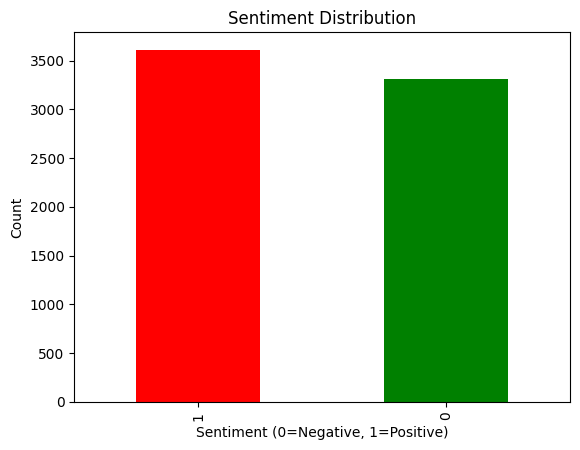


Sample Texts:
0    a stirring , funny and finally transporting re...
1    apparently reassembled from the cutting room f...
2    they presume their audience wo n't sit still f...
Name: text, dtype: object


In [43]:
import matplotlib.pyplot as plt
# Shape of dataset
print("Total samples:", df.shape[0])

# Class distribution
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

# Visualize
df['sentiment'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment (0=Negative, 1=Positive)')
plt.ylabel('Count')
plt.show()

# Sample texts
print("\nSample Texts:")
print(df['text'].head(3))

##NLP Preprocessing

In [44]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower() # conversion to lower case
    text = re.sub(r'http\S+|www\S+', '', text) # removes the urls
    text = re.sub(r'[^\w\s]', '', text) # removes puntuations
    text = re.sub(r'\d+', '', text)     # removes numbers
    text = re.sub(r'\s+', ' ', text).strip() # removes extra spaces
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)  # returns string

df['cleaned'] = df['text'].apply(preprocess_text)
print(df[['text', 'cleaned']].head(3))

                                                text  \
0  a stirring , funny and finally transporting re...   
1  apparently reassembled from the cutting room f...   
2  they presume their audience wo n't sit still f...   

                                             cleaned  
0  stirring funny finally transporting imagining ...  
1  apparently reassembled cutting room floor give...  
2  presume audience wo nt sit still sociology les...  


##Feature Engineering


In [45]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['cleaned']
y = df['sentiment']

# splitting the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# vectorization of train data

# bag of words
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW shape:", X_train_bow.shape)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)


Training samples: 5536
Testing samples: 1384
BoW shape: (5536, 11127)
TF-IDF shape: (5536, 11127)


##Model Building

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# trining the model on train dataset

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    print(f"{name} trained")

Logistic Regression trained
Naive Bayes trained
Decision Tree trained
Random Forest trained
XGBoost trained


##Model Evaluation

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

# evaluating the models

for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1 Score": round(f1_score(y_test, y_pred), 3)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.788      0.760   0.861     0.807
1          Naive Bayes     0.790      0.749   0.889     0.813
2        Decision Tree     0.661      0.655   0.722     0.687
3        Random Forest     0.745      0.722   0.820     0.768
4              XGBoost     0.711      0.680   0.829     0.747


##Comparison & Insights

**Best Preprocessing:** Lemmatization with stopword removal gave cleaner
tokens than stemming.

**Best Vectorization:** TF-IDF performed well as it gives more importance
to meaningful rare words over common ones.

**Best Model:** Naive Bayes with 79% accuracy and highest F1 score of 0.813.

**Worst Model:** Decision Tree at 66.7% — tends to overfit on text data.

**Trade-offs:**
- Logistic Regression is slower to train but more stable than Naive Bayes.
- Decision Tree is interpretable but performs poorly on high dimensional text data.
- Naive Bayes is fast and works well with TF-IDF on small datasets.
- Random Forest achieved 73.1% accuracy but is slower to train due to the formation of larger trees.
- XGBoost achieved 71.1% accuracy and works better with larger datasets.

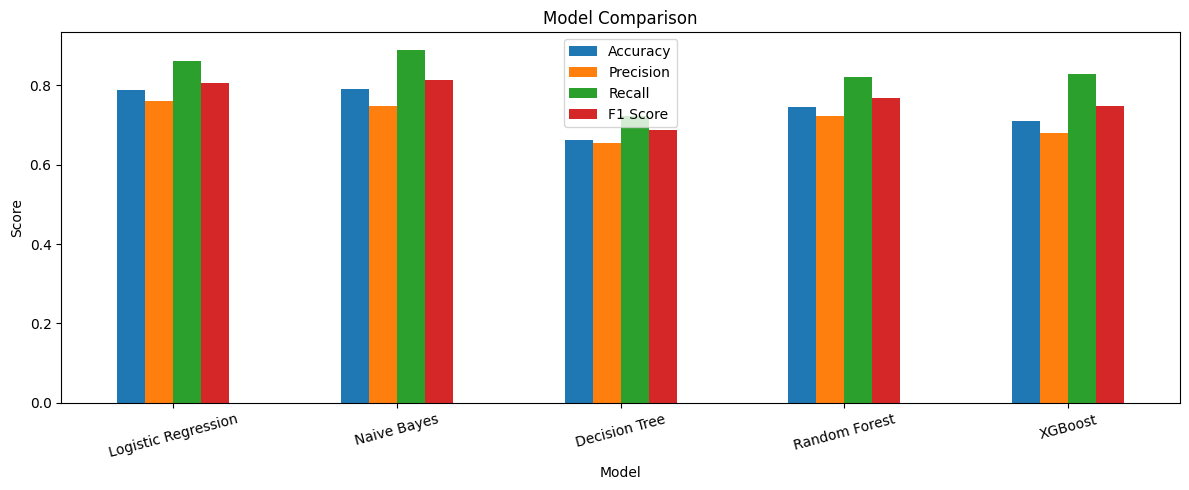

In [48]:
import matplotlib.pyplot as plt
results_df.plot(x='Model', kind='bar', figsize=(12,5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()